In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import pandas as pd
import numpy as np
import os

# These are the paths where Kaggle mounts the competition data
TRANS_PATH = '/kaggle/input/competitions/h-and-m-personalized-fashion-recommendations/transactions_train.csv'
CUST_PATH = '/kaggle/input/competitions/h-and-m-personalized-fashion-recommendations/customers.csv'
ART_PATH = '/kaggle/input/competitions/h-and-m-personalized-fashion-recommendations/articles.csv'

# Output directory for saving Parquet files
OUT_DIR = '/kaggle/working/'

In [3]:
# Load full customers file - this is only ~1.37M rows and manageable
customers = pd.read_csv(CUST_PATH)

print(f"Total customers: {len(customers)}")
print(customers.head())
print(customers.dtypes)
print(customers.isnull().sum())

Total customers: 1371980
                                         customer_id   FN  Active  \
0  00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...  NaN     NaN   
1  0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...  NaN     NaN   
2  000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...  NaN     NaN   
3  00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...  NaN     NaN   
4  00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...  1.0     1.0   

  club_member_status fashion_news_frequency   age  \
0             ACTIVE                   NONE  49.0   
1             ACTIVE                   NONE  25.0   
2             ACTIVE                   NONE  24.0   
3             ACTIVE                   NONE  54.0   
4             ACTIVE              Regularly  52.0   

                                         postal_code  
0  52043ee2162cf5aa7ee79974281641c6f11a68d276429a...  
1  2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...  
2  64f17e6a330a85798e4998f62d0930d14db8db1c054af6...  
3  5d36574f52495e81f0

In [4]:
# Set a seed so your subset is reproducible every time you run the notebook
np.random.seed(42)

sampled_customer_ids = customers['customer_id'].sample(n=100_000, random_state=42).values
sampled_set = set(sampled_customer_ids)  # set lookup is O(1), much faster than list

print(f"Sampled {len(sampled_customer_ids)} customers")

Sampled 100000 customers


In [5]:
chunk_list = []
chunk_size = 500_000  # Load 500K rows at a time

for chunk in pd.read_csv(TRANS_PATH, chunksize=chunk_size, dtype={'article_id': str}):
    # Keep only rows belonging to our 100K sampled customers
    filtered = chunk[chunk['customer_id'].isin(sampled_set)]
    chunk_list.append(filtered)
    print(f"Processed chunk, kept {len(filtered)} rows")

transactions = pd.concat(chunk_list, ignore_index=True)
print(f"\nFinal transaction rows for 100K customers: {len(transactions)}")

Processed chunk, kept 36252 rows
Processed chunk, kept 36643 rows
Processed chunk, kept 35601 rows
Processed chunk, kept 36166 rows
Processed chunk, kept 36439 rows
Processed chunk, kept 35580 rows
Processed chunk, kept 35823 rows
Processed chunk, kept 35578 rows
Processed chunk, kept 35568 rows
Processed chunk, kept 36151 rows
Processed chunk, kept 35578 rows
Processed chunk, kept 36092 rows
Processed chunk, kept 35356 rows
Processed chunk, kept 36638 rows
Processed chunk, kept 36000 rows
Processed chunk, kept 36174 rows
Processed chunk, kept 35503 rows
Processed chunk, kept 36311 rows
Processed chunk, kept 36549 rows
Processed chunk, kept 37664 rows
Processed chunk, kept 36619 rows
Processed chunk, kept 36464 rows
Processed chunk, kept 35527 rows
Processed chunk, kept 35524 rows
Processed chunk, kept 37277 rows
Processed chunk, kept 35500 rows
Processed chunk, kept 35452 rows
Processed chunk, kept 36481 rows
Processed chunk, kept 35169 rows
Processed chunk, kept 36552 rows
Processed 

In [6]:
# Parse date column properly
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])

# Check for nulls
print("Nulls in transactions:")
print(transactions.isnull().sum())

# Drop rows where critical columns are null
transactions.dropna(subset=['customer_id', 'article_id', 'price'], inplace=True)

# Confirm date range
print(f"\nDate range: {transactions['t_dat'].min()} to {transactions['t_dat'].max()}")
print(f"Unique customers: {transactions['customer_id'].nunique()}")
print(f"Unique articles: {transactions['article_id'].nunique()}")

Nulls in transactions:
t_dat               0
customer_id         0
article_id          0
price               0
sales_channel_id    0
dtype: int64

Date range: 2018-09-20 00:00:00 to 2020-09-22 00:00:00
Unique customers: 99345
Unique articles: 81940


In [7]:
# Filter customers table to only your 100K sampled customers
customers = customers[customers['customer_id'].isin(sampled_set)].copy()

# Age has a lot of nulls - bin into groups instead of imputing a fake number
# Unknown is a valid category - don't drop these rows
def age_bin(age):
    if pd.isnull(age):
        return 'Unknown'
    elif age < 25:
        return 'Gen Z'
    elif age < 35:
        return 'Millennial'
    elif age < 50:
        return 'Gen X'
    else:
        return 'Boomer+'

customers['age_group'] = customers['age'].apply(age_bin)

# Clean up club_member_status and fashion_news_frequency nulls
customers['club_member_status'].fillna('UNKNOWN', inplace=True)
customers['fashion_news_frequency'].fillna('NONE', inplace=True)

print(customers['age_group'].value_counts())
print(customers['club_member_status'].value_counts())
print(customers['fashion_news_frequency'].value_counts())

age_group
Millennial    28374
Gen Z         26120
Boomer+       23249
Gen X         21083
Unknown        1174
Name: count, dtype: int64
club_member_status
ACTIVE        92733
PRE-CREATE     6781
UNKNOWN         448
LEFT CLUB        38
Name: count, dtype: int64
fashion_news_frequency
NONE         65288
Regularly    34663
Monthly         49
Name: count, dtype: int64


/tmp/ipykernel_16/1765450253.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customers['club_member_status'].fillna('UNKNOWN', inplace=True)
/tmp/ipykernel_16/1765450253.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace

In [8]:
articles = pd.read_csv(ART_PATH, dtype={'article_id': str})

print(f"Total articles: {len(articles)}")
print(articles.columns.tolist())
print(articles.isnull().sum())

# Fill missing descriptions with empty string - NLP step later will handle it
articles['detail_desc'].fillna('', inplace=True)

# Keep only articles that actually appear in your filtered transactions
active_article_ids = transactions['article_id'].unique()
articles = articles[articles['article_id'].isin(active_article_ids)].copy()

print(f"Articles after filtering to active only: {len(articles)}")

Total articles: 105542
['article_id', 'product_code', 'prod_name', 'product_type_no', 'product_type_name', 'product_group_name', 'graphical_appearance_no', 'graphical_appearance_name', 'colour_group_code', 'colour_group_name', 'perceived_colour_value_id', 'perceived_colour_value_name', 'perceived_colour_master_id', 'perceived_colour_master_name', 'department_no', 'department_name', 'index_code', 'index_name', 'index_group_no', 'index_group_name', 'section_no', 'section_name', 'garment_group_no', 'garment_group_name', 'detail_desc']
article_id                        0
product_code                      0
prod_name                         0
product_type_no                   0
product_type_name                 0
product_group_name                0
graphical_appearance_no           0
graphical_appearance_name         0
colour_group_code                 0
colour_group_name                 0
perceived_colour_value_id         0
perceived_colour_value_name       0
perceived_colour_master_id    

/tmp/ipykernel_16/2880164522.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  articles['detail_desc'].fillna('', inplace=True)


Articles after filtering to active only: 81940


In [9]:
transactions.to_parquet(os.path.join(OUT_DIR, 'transactions_clean.parquet'), index=False)
customers.to_parquet(os.path.join(OUT_DIR, 'customers_clean.parquet'), index=False)
articles.to_parquet(os.path.join(OUT_DIR, 'articles_clean.parquet'), index=False)

print("All three files saved as Parquet")
print(f"Transactions shape: {transactions.shape}")
print(f"Customers shape: {customers.shape}")
print(f"Articles shape: {articles.shape}")

All three files saved as Parquet
Transactions shape: (2296723, 5)
Customers shape: (100000, 8)
Articles shape: (81940, 25)



Purchase frequency stats:
count    99345.000000
mean        23.118657
std         38.071822
min          1.000000
25%          3.000000
50%          9.000000
75%         27.000000
max       1237.000000
Name: article_id, dtype: float64


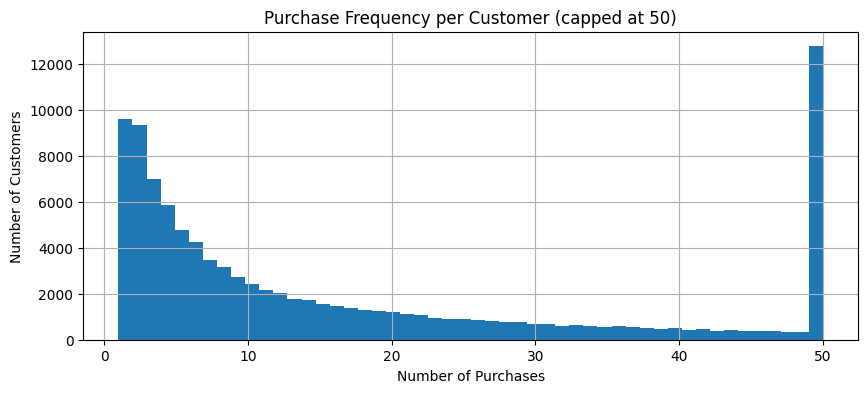

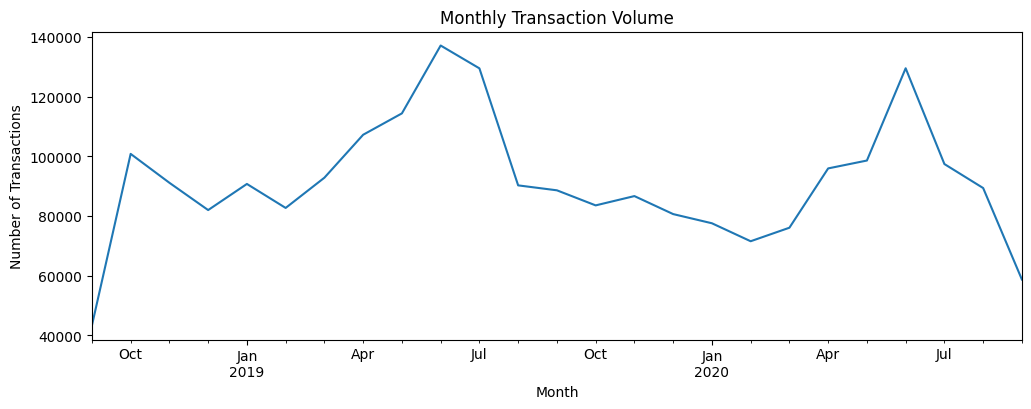

In [10]:
import matplotlib.pyplot as plt

# Purchase frequency distribution
purchase_counts = transactions.groupby('customer_id')['article_id'].count()
print(f"\nPurchase frequency stats:")
print(purchase_counts.describe())

plt.figure(figsize=(10, 4))
purchase_counts.clip(upper=50).hist(bins=50)
plt.title('Purchase Frequency per Customer (capped at 50)')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Customers')
plt.show()

# Monthly transaction volume
transactions['month'] = transactions['t_dat'].dt.to_period('M')
monthly = transactions.groupby('month').size()

plt.figure(figsize=(12, 4))
monthly.plot()
plt.title('Monthly Transaction Volume')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.show()

In [11]:
# transactions.to_parquet('/kaggle/working/transactions.parquet')

In [12]:
transactions['t_dat'].head()

0   2018-09-20
1   2018-09-20
2   2018-09-20
3   2018-09-20
4   2018-09-20
Name: t_dat, dtype: datetime64[ns]